## Unsupervised Learning - Myocardial Infarction Prediction
BRFSS 2024 · Identifying Groups Most Impacted by `_MICHD`· Owner: Mubashar Khan


## **1. Setup & Imports**

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd /content
!git clone https://github.com/ALEE0001/model_myocardial_infarction.git
%cd model_myocardial_infarction

%cd /content/model_myocardial_infarction
!git pull

/content
fatal: destination path 'model_myocardial_infarction' already exists and is not an empty directory.
/content/model_myocardial_infarction
/content/model_myocardial_infarction
Already up to date.


In [3]:
# Install prince and kmodes for dimensionality reduction and clustering
!pip install prince --quiet
!pip install kmodes --quiet

In [4]:
# Standard Libraries
import pickle
import json
import warnings
warnings.filterwarnings("ignore")

# Preprocessing & Sampling
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Dimensionality Reduction
import prince  # FAMD

# Clustering
from kmodes.kprototypes import KPrototypes
from sklearn.mixture import GaussianMixture

# Evaluation
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
from tqdm import tqdm

print("All imports successful.")

All imports successful.


In [5]:
data_path = '/content/drive/MyDrive/Colab Notebooks/processed_data_v2.csv'
df = pd.read_csv(data_path, low_memory=False)

TARGET = "_MICHD"

with open("/content/drive/MyDrive/Colab Notebooks/selected_features_v2.pkl", "rb") as f:
    selected_features = pickle.load(f)

FEATURES = list(selected_features)

# Drop rows where target is missing
df = df[df[TARGET].notna()].copy()

# Work only on selected features + target
df_model = df[FEATURES + [TARGET]].copy()

# Define column types based on cardinality and dtype
# Threshold of 10 unique values flags a column as categorical
categorical_cols = [
    c for c in FEATURES
    if df_model[c].dtype == "object"
    or df_model[c].dtype.name == "category"
    or df_model[c].nunique() <= 10
]
continuous_cols = [
    c for c in FEATURES
    if c not in categorical_cols
    and pd.api.types.is_numeric_dtype(df_model[c])
]

print(f"Selected features: {len(FEATURES)}")
print(f"  Categorical : {len(categorical_cols)}")
print(f"  Continuous  : {len(continuous_cols)}")

Selected features: 27
  Categorical : 21
  Continuous  : 6


Of the 27 selected features, 21 were identified as categorical and 6 as continuous. Classification was determined by dtype and cardinality. Any feature with an object or category dtype, or with 10 or fewer unique values, was treated as categorical. Remaining numeric features were treated as continuous. This distinction is necessary for FAMD and K-Prototypes, both of which handle categorical and continuous variables differently.

## **2. Data Preprocessing Before Clustering**

In [6]:
# Impute continuous with median, categorical with mode

df_model[continuous_cols] = df_model[continuous_cols].fillna(
    df_model[continuous_cols].median()
)

for col in categorical_cols:
    mode_val = df_model[col].mode()[0]
    df_model[col] = df_model[col].fillna(mode_val)

# Cast categorical cols to str so downstream encoders are consistent
df_model[categorical_cols] = df_model[categorical_cols].astype(str)

missing = df_model[FEATURES].isnull().sum().sum()
print(f"Remaining missing values in features: {missing}")
print(f"Working dataset shape: {df_model.shape}")

Remaining missing values in features: 0
Working dataset shape: (452464, 28)


In [7]:
SAMPLE_SIZE = 50000  # large enough for stable clusters, fast enough to iterate

# Stratified sample to preserve MICHD ratio
df_sample, _ = train_test_split(
    df_model,
    train_size=SAMPLE_SIZE,
    stratify=df_model[TARGET],
    random_state=42
)

print(f"Sample shape: {df_sample.shape}")
print(f"MICHD rate — full: {df_model[TARGET].mean():.3f} | sample: {df_sample[TARGET].mean():.3f}")

Sample shape: (50000, 28)
MICHD rate — full: 0.094 | sample: 0.094


Missing values were imputed using median imputation for continuous features and mode imputation for categorical features, after which all categorical columns were cast to string type for compatibility with FAMD's internal encoder. Additionally, a stratified sample of 50,000 records was drawn from the full dataset to reduce computational cost for FAMD fitting and clustering. Stratification on the MICHD target preserved the original class ratio exactly (9.4% in both full and sample), ensuring the sample is representative of the population's MI/CHD burden.

## **3. FAMD (Factor Analysis of Mixed Data) Dimensionality Reduction**

FAMD was chosen as the dimensionality reduction method because the BRFSS dataset contains both categorical and continuous features, making standard PCA inappropriate. FAMD generalizes PCA to handle mixed data types by applying PCA to continuous variables and MCA (Multiple Correspondence Analysis) to categorical variables simultaneously.

50% variance explained → 29 components (component index 28)
60% variance explained → 38 components (component index 37)
70% variance explained → 48 components (component index 47)
80% variance explained → 58 components (component index 57)

Eigenvalues summary (first 15):
          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              4.828         5.42%                      5.42%
1              4.629         5.20%                     10.63%
2              2.938         3.30%                     13.93%
3              2.606         2.93%                     16.85%
4              1.871         2.10%                     18.96%
5              1.720         1.93%                     20.89%
6              1.607         1.81%                     22.69%
7              1.528         1.72%                     24.41%
8              1.375         1.54%                     25.96%
9              1.317         1.48%           

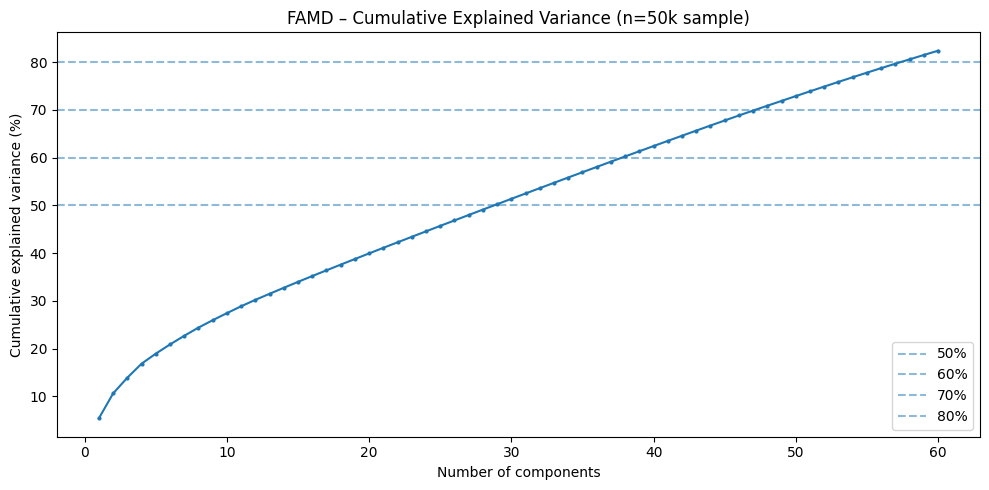

In [8]:
# Search for variance threshold on sample
famd_input_sample = df_sample[FEATURES].copy()
famd_input_sample[continuous_cols] = famd_input_sample[continuous_cols].astype(float)
famd_input_sample[categorical_cols] = famd_input_sample[categorical_cols].astype(str)

famd_input_full = df_model[FEATURES].copy()
famd_input_full[continuous_cols] = famd_input_full[continuous_cols].astype(float)
famd_input_full[categorical_cols] = famd_input_full[categorical_cols].astype(str)

N_COMPONENTS_SEARCH = 60

famd = prince.FAMD(n_components=N_COMPONENTS_SEARCH, n_iter=10, random_state=42, engine="sklearn")
famd.fit(famd_input_sample)  # fit on 50k sample only

cumvar = famd.cumulative_percentage_of_variance_

thresholds = [50, 60, 70, 80]
for t in thresholds:
    hits = [i for i, v in enumerate(cumvar) if v >= t]
    if hits:
        print(f"{t}% variance explained → {hits[0]+1} components (component index {hits[0]})")
    else:
        print(f"{t}% variance explained → not reached within {N_COMPONENTS_SEARCH} components")

print(f"\nEigenvalues summary (first 15):")
print(famd.eigenvalues_summary.head(15))

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumvar)+1), cumvar, marker=".", markersize=4)
for t in thresholds:
    plt.axhline(t, linestyle="--", alpha=0.5, label=f"{t}%")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance (%)")
plt.title("FAMD – Cumulative Explained Variance (n=50k sample)")
plt.legend()
plt.tight_layout()
plt.savefig("famd_cumulative_variance.png", dpi=150, bbox_inches="tight")
plt.show()

To determine the optimal number of components, FAMD was first fit on the 50k stratified sample with 60 components as an upper bound. The eigenvalues summary revealed a gradual variance explained per component: the top two components captured 5.42% and 5.20% with subsequent components contributing incrementally smaller amounts. Cumulative explained variance was then evaluated at four thresholds (50%, 60%, 70%, and 80%) corresponding to 30, 39, 48, and 58 components. The plot shows a smooth, near-linear increase in cumulative explained variance with no sharp elbow, characteristic of mixed survey data where variance is distributed diffusely across many features. The 80% threshold is reached at 58 components, which was selected as the final FAMD embedding dimensionality.

In [9]:
N_COMPONENTS = 60  # must match N_COMPONENTS_SEARCH
N_FINAL = 58       # 80% variance threshold

famd = prince.FAMD(n_components=N_COMPONENTS, n_iter=10, random_state=42, engine="sklearn")
famd.fit(famd_input_sample)

# Fix unseen categories before transforming full dataset
for col in categorical_cols:
    known_cats = set(famd.categories_[col])
    mode_val = df_sample[col].astype(str).mode()[0]
    mask = ~famd_input_full[col].isin(known_cats)
    if mask.any():
        print(f"{col}: {famd_input_full[col][mask].unique()} → replacing with '{mode_val}'")
        famd_input_full.loc[mask, col] = mode_val

# Transform both
famd_coords_sample = famd.transform(famd_input_sample)
famd_coords_full   = famd.transform(famd_input_full)

famd_coords_sample.columns = [f"FAMD_{i+1}" for i in range(N_COMPONENTS)]
famd_coords_full.columns   = [f"FAMD_{i+1}" for i in range(N_COMPONENTS)]
famd_coords_sample.index = df_sample.index
famd_coords_full.index   = df_model.index

# Trim to N_FINAL components
famd_sample_final = famd_coords_sample.iloc[:, :N_FINAL].values
famd_full_final   = famd_coords_full.iloc[:, :N_FINAL].values

print(f"FAMD sample shape : {famd_sample_final.shape}")
print(f"FAMD full shape   : {famd_full_final.shape}")

MARITAL: ['Unknown'] → replacing with 'Married'
FAMD sample shape : (50000, 58)
FAMD full shape   : (452464, 58)


Following the component search, FAMD was refit on the 50k sample using 60 components and applied to transform both the sample and full dataset. Prior to transforming the full dataset, one unseen category was detected. The value 'Unknown' in the MARITAL column was absent from the sample's training categories and was replaced with the sample mode ('Married') to ensure compatibility with the fitted encoder. This sample embedding will be used exclusively for model fitting while the full embedding is reserved for final cluster assignments across all records.

In [10]:
# Column contributions
contrib = famd.column_contributions_

for comp in range(4):
    print(f"\n--- Component {comp} ---")
    print(contrib[comp].abs().sort_values(ascending=False).head(8))


--- Component 0 ---
variable
DIFFDRES    0.166115
DIFFWALK    0.166109
DIFFALON    0.162078
DEAF        0.138870
_SMOKER3    0.129724
PNEUVAC4    0.079308
_INCOMG1    0.020990
VETERAN3    0.017484
Name: 0, dtype: float64

--- Component 1 ---
variable
DIFFWALK    0.105738
_AGEG5YR    0.067995
DIFFALON    0.063941
DIFFDRES    0.062819
PRIMINS2    0.060878
PHYSHLTH    0.055530
_RFHLTH     0.053610
HAVARTH4    0.051072
Name: 1, dtype: float64

--- Component 2 ---
variable
PRIMINS2    0.119700
_AGEG5YR    0.103256
MARITAL     0.091478
_INCOMG1    0.062208
_LCSYQTS    0.061773
PERSDOC3    0.053743
DIFFALON    0.051118
POORHLTH    0.050923
Name: 2, dtype: float64

--- Component 3 ---
variable
DIABETE4    0.117486
HAVARTH4    0.117181
DIFFDRES    0.115757
CHCCOPD3    0.110998
DIFFALON    0.110518
DIFFWALK    0.095540
CHCOCNC1    0.086009
CHCKDNY2    0.065338
Name: 3, dtype: float64



The first four FAMD components capture different health and demographic dimensions within the BRFSS data.

*   Component 0 is dominated by functional disability indicators: DIFFWALK, DIFFDRES, and DIFFALON (difficulty walking, dressing, and being alone) alongside DEAF and _SMOKER3
*   Component 1 similarly loads on mobility difficulty but adds age (_AGEG5YR), general health (_RFHLTH), physical health days (PHYSHLTH), and insurance status (PRIMINS2)
*   Component 2 shifts toward socioeconomic and demographic factors, with primary insurance (PRIMINS2), age, marital status (MARITAL), and income (_INCOMG1) as top contributors
*   Component 3 loads heavily on chronic disease comorbidities — diabetes (DIABETE4), arthritis (HAVARTH4), COPD (CHCCOPD3), and kidney disease (CHCKDNY2), alongside mobility difficulty






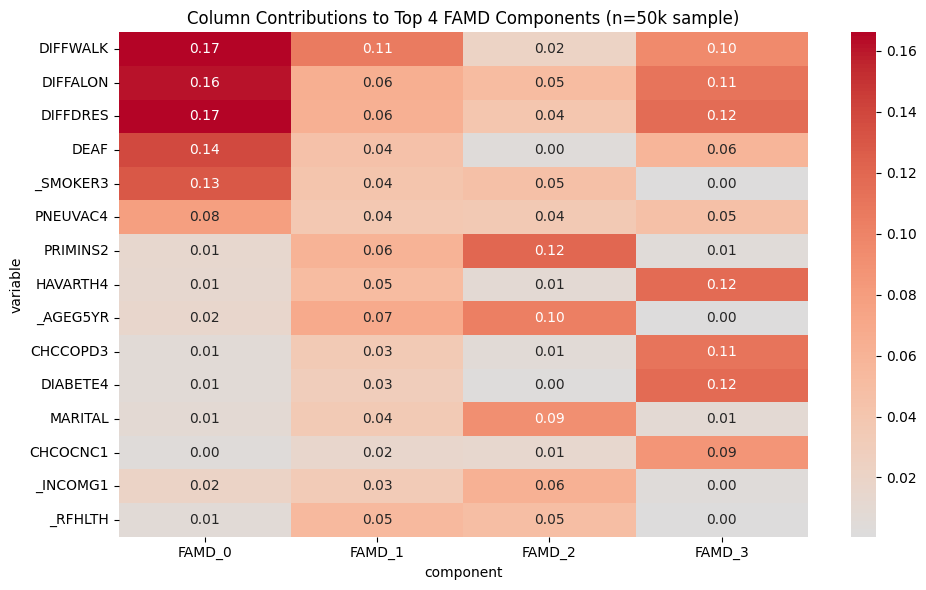

In [11]:
# Contributions heatmap
top_vars = contrib.iloc[:, :4].abs().sum(axis=1).sort_values(ascending=False).head(15).index

plt.figure(figsize=(10, 6))
sns.heatmap(
    contrib.loc[top_vars, list(range(4))],
    annot=True, fmt=".2f", cmap="coolwarm", center=0,
    xticklabels=[f"FAMD_{i}" for i in range(4)],
    yticklabels=top_vars
)
plt.title("Column Contributions to Top 4 FAMD Components (n=50k sample)")
plt.tight_layout()
plt.savefig("famd_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## **4. K-Prototype Clustering**


K-Prototypes was selected as the first clustering method because the BRFSS dataset contains a mix of categorical and continuous features. Standard K-Means is unsuitable for categorical data as it relies on Euclidean distance, which is not meaningful for nominal variables. K-Prototypes addresses this by combining K-Means-style Euclidean distance for continuous features with K-Modes-style Hamming distance for categorical features, making it a good fit for mixed-type health survey data.

K-Prototypes elbow: 100%|██████████| 7/7 [20:08<00:00, 172.70s/it]


Marginal gains:
  k=3: -46,591
  k=4: -36,003
  k=5: -24,190
  k=6: -16,494
  k=7: -7,809
  k=8: -8,640


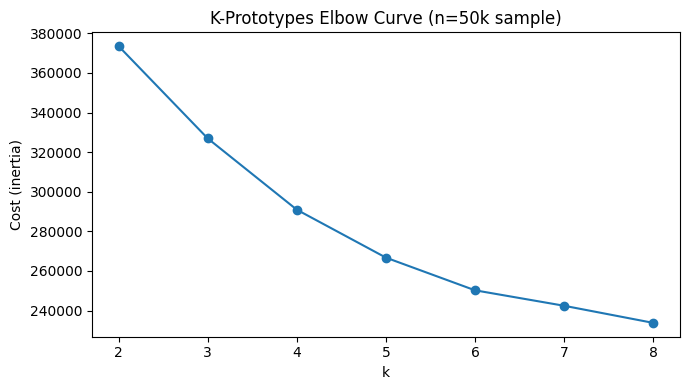

In [16]:
# K-Prototypes elbow on sample (15-20 min to run)
scaler = StandardScaler()
X_cont_scaled_sample = scaler.fit_transform(df_sample[continuous_cols].astype(float))
X_cont_scaled_full   = scaler.transform(df_model[continuous_cols].astype(float))

X_kproto_sample = np.concatenate([X_cont_scaled_sample, df_sample[categorical_cols].values], axis=1)
X_kproto_full   = np.concatenate([X_cont_scaled_full,   df_model[categorical_cols].values], axis=1)

cat_idx = list(range(len(continuous_cols), len(continuous_cols) + len(categorical_cols)))

K_RANGE = range(2, 9)
costs, all_labels = [], []

for k in tqdm(K_RANGE, desc="K-Prototypes elbow"):
    kp = KPrototypes(n_clusters=k, init="Huang", n_init=3, random_state=42, verbose=0)
    labels = kp.fit_predict(X_kproto_sample, categorical=cat_idx)
    costs.append(kp.cost_)
    all_labels.append(labels)

# Marginal gains
gains = [costs[i-1] - costs[i] for i in range(1, len(costs))]
ks = list(K_RANGE)[1:]
print("Marginal gains:")
for k, g in zip(ks, gains):
    print(f"  k={k}: -{g:,.0f}")

plt.figure(figsize=(7, 4))
plt.plot(list(K_RANGE), costs, marker="o")
plt.xlabel("k")
plt.ylabel("Cost (inertia)")
plt.title("K-Prototypes Elbow Curve (n=50k sample)")
plt.tight_layout()
plt.savefig("kproto_elbow.png", dpi=150, bbox_inches="tight")
plt.show()

To determine the optimal number of clusters, K-Prototypes was fit on the 50k stratified sample across k=2 to k=8 using the Huang initialization method with 3 random initializations per k. Continuous features were standardized prior to fitting and categorical column indices were passed explicitly to the algorithm. The cost (total inertia) was recorded at each k and marginal gains were computed as the reduction in cost from adding one additional cluster. The elbow curve showed a smooth decline with the most significant drops at k=3 and k=4, after which gains diminished sharply. The largest change in marginal improvement occurred between k=4 and k=5, where the gain dropped by approximately 33%, and k=8 showed slight cost increase over k=7 indicating instability. Based on this analysis k=4 was selected as the optimal number of clusters.

Silhouette scores:
  k=2: 0.153
  k=3: 0.047
  k=4: 0.029
  k=5: 0.022
  k=6: 0.020
  k=7: 0.018
  k=8: 0.012

Davies-Bouldin scores:
  k=2: 3.371
  k=3: 3.982
  k=4: 3.944
  k=5: 3.911
  k=6: 3.878
  k=7: 5.423
  k=8: 5.483


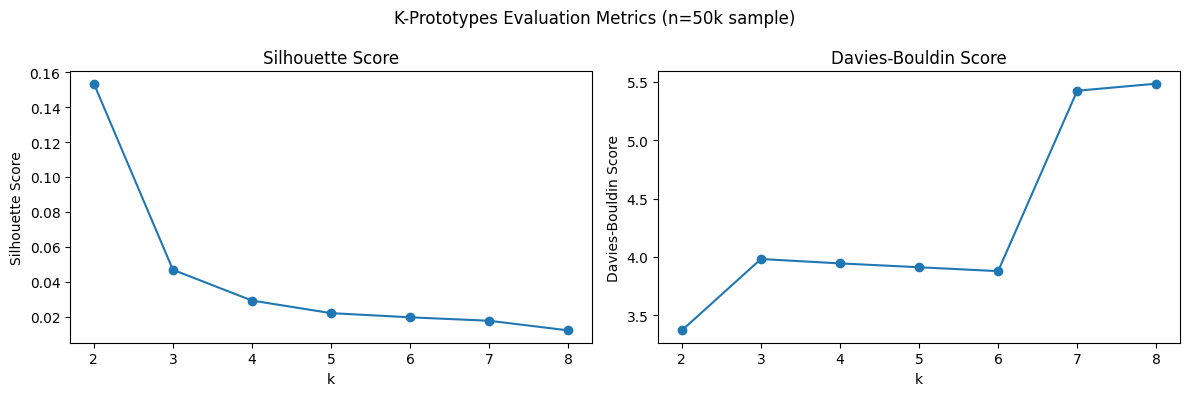

In [17]:
# Silhouette and Davies-Bouldin across k
sil_scores, db_scores = [], []

for labels in all_labels:
    sil_scores.append(silhouette_score(famd_sample_final, labels, sample_size=5000, random_state=42))
    db_scores.append(davies_bouldin_score(famd_sample_final, labels))

print("Silhouette scores:")
for k, s in zip(K_RANGE, sil_scores):
    print(f"  k={k}: {s:.3f}")

print("\nDavies-Bouldin scores:")
for k, d in zip(K_RANGE, db_scores):
    print(f"  k={k}: {d:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_RANGE), sil_scores, marker="o")
axes[0].set_title("Silhouette Score")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Silhouette Score")

axes[1].plot(list(K_RANGE), db_scores, marker="o")
axes[1].set_title("Davies-Bouldin Score")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Davies-Bouldin Score")

plt.suptitle("K-Prototypes Evaluation Metrics (n=50k sample)")
plt.tight_layout()
plt.savefig("kproto_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

Two metrics were used to evaluate cluster quality across k=2 to k=8. Silhouette score measures how similar points are to their own cluster compared to other clusters (higher is better). Davies-Bouldin score measures the ratio of within-cluster spread to between-cluster separation (lower is better).
Silhouette scores decreased steadily from 0.153 at k=2 to 0.012 at k=8, while Davies-Bouldin scores remained relatively stable from k=3 to k=6 before spiking at k=7 and k=8, indicating instability at higher k values. Although silhouette technically peaks at k=2, a two-cluster solution is too broad to identify meaningful subgroups within the data. Combined with the marginal gains analysis showing the sharpest drop at k=4→5, we will use k=4 as the optimal number of clusters.

In [31]:
K_BEST = 4

kproto_final = KPrototypes(
    n_clusters=K_BEST, init="Huang", n_init=5, random_state=42, verbose=1
)
kproto_final.fit(X_kproto_sample, categorical=cat_idx)

# Assign to full dataset
df_model["kproto_cluster"] = kproto_final.predict(X_kproto_full, categorical=cat_idx)

print(df_model["kproto_cluster"].value_counts().sort_index())
print(f"\nMICHD rate per cluster:")
michd_rates_kp = df_model.groupby("kproto_cluster")[TARGET].mean().round(3)
print(michd_rates_kp)

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 15259, ncost: 314536.6280073201
Run: 1, iteration: 2/100, moves: 7446, ncost: 302967.8317750143
Run: 1, iteration: 3/100, moves: 5417, ncost: 292947.36582948454
Run: 1, iteration: 4/100, moves: 2167, ncost: 290935.5489338483
Run: 1, iteration: 5/100, moves: 333, ncost: 290900.03308707336
Run: 1, iteration: 6/100, moves: 23, ncost: 290899.565450824
Run: 1, iteration: 7/100, moves: 0, ncost: 290899.565450824
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 2, iteration: 1/100, moves: 15503, ncost: 294204.01263055735
Run: 2, iteration: 2/100, moves: 3061, ncost: 292064.0399040268
Run: 2, iteration: 3/100, moves: 1004, ncost: 291098.3654444065
Run: 2, iteration: 4/100, moves: 351, ncost: 291033.42446926684
Run: 2, iteration: 5/100, moves: 68, ncost: 291031.5318075258
Run: 2, iteration: 6/100, moves: 8, ncost: 291031.4973091607
Run: 2, iteratio

The final K-Prototypes model with k=4 assigned all 452,464 records to one of four clusters. Cluster 3 was the largest with 195,458 members and had by far the lowest MICHD rate at 1.8%, representing a low-risk population. Cluster 2 was the second largest with 172,795 members at a 12.6% MICHD rate, representing a medium-risk group. Clusters 0 and 1 were smaller at 48,089 and 36,122 members, but carried the highest MICHD burden at 22.3% and 17.1% (more than 12 times the rate of Cluster 3). The 20.5 percentage point spread in MICHD rates across clusters confirms that K-Prototypes successfully identified clinically meaningful risk stratification within the BRFSS population.

In [32]:
# Top 5 most distinguishing features per cluster (continuous only via z-score)
global_means = df_model[continuous_cols].mean()
global_stds  = df_model[continuous_cols].std()

cluster_means = df_model.groupby("kproto_cluster")[continuous_cols].mean()
deviations = (cluster_means - global_means) / global_stds

print("=== Top 5 most distinguishing continuous features per cluster ===")
for k in sorted(df_model["kproto_cluster"].unique()):
    print(f"\nCluster {k} (MICHD rate: {df_model.groupby('kproto_cluster')[TARGET].mean()[k]:.1%}):")
    top5 = deviations.loc[k].abs().sort_values(ascending=False).head(5)
    for feat in top5.index:
        direction = "↑" if deviations.loc[k, feat] > 0 else "↓"
        print(f"  {direction} {feat}: {deviations.loc[k, feat]:+.2f} SD from mean")

# For categorical features show most deviant mode per cluster
print("\n=== Top 5 most distinguishing categorical features per cluster ===")
global_modes = df_model[categorical_cols].agg(lambda x: x.mode()[0])
cat_modes = df_model.groupby("kproto_cluster")[categorical_cols].agg(lambda x: x.mode()[0])

for k in sorted(df_model["kproto_cluster"].unique()):
    print(f"\nCluster {k}:")
    # Show features where cluster mode differs from global mode
    diffs = cat_modes.loc[k][cat_modes.loc[k] != global_modes]
    print(diffs.head(5).to_string())

=== Top 5 most distinguishing continuous features per cluster ===

Cluster 0 (MICHD rate: 22.3%):
  ↑ PHYSHLTH: +2.40 SD from mean
  ↑ POORHLTH: +2.00 SD from mean
  ↑ _LCSYSMK: +0.46 SD from mean
  ↑ _AGEG5YR: +0.27 SD from mean
  ↑ LCSNUMCG: +0.24 SD from mean

Cluster 1 (MICHD rate: 17.1%):
  ↑ _LCSYQTS: +2.61 SD from mean
  ↓ _LCSYSMK: -1.13 SD from mean
  ↑ _AGEG5YR: +0.90 SD from mean
  ↑ LCSNUMCG: +0.77 SD from mean
  ↓ POORHLTH: -0.15 SD from mean

Cluster 2 (MICHD rate: 12.6%):
  ↑ _AGEG5YR: +0.78 SD from mean
  ↑ _LCSYSMK: +0.42 SD from mean
  ↓ PHYSHLTH: -0.29 SD from mean
  ↓ POORHLTH: -0.24 SD from mean
  ↓ _LCSYQTS: -0.18 SD from mean

Cluster 3 (MICHD rate: 1.8%):
  ↓ _AGEG5YR: -0.93 SD from mean
  ↓ PHYSHLTH: -0.31 SD from mean
  ↓ _LCSYSMK: -0.28 SD from mean
  ↓ _LCSYQTS: -0.28 SD from mean
  ↓ POORHLTH: -0.25 SD from mean

=== Top 5 most distinguishing categorical features per cluster ===

Cluster 0:
_TOTINDA              0.0
_INCOMG1          Unknown
PERSDOC3    Mor

Cluster 0 (22.3% MICHD) is defined by severely elevated poor health days (PHYSHLTH +2.40 SD, POORHLTH +2.00 SD), active smoking, arthritis, and multiple doctors. Cluster 1 (17.1% MICHD) represents elderly long-term ex-smokers, characterized by the longest time since quitting (_LCSYQTS +2.61 SD), oldest age, and Medicare insurance, where historical smoking drives elevated risk despite decent current health. Cluster 2 (12.6% MICHD) is defined primarily by older age (+0.78 SD) with Medicare coverage, representing a moderately older but otherwise healthy group. Cluster 3 (1.8% MICHD) is the youngest and healthiest group with no distinguishing categorical features, confirming it as the baseline low-risk population. Overall, active physical health burden and smoking history emerge as the strongest drivers of MICHD risk across clusters.

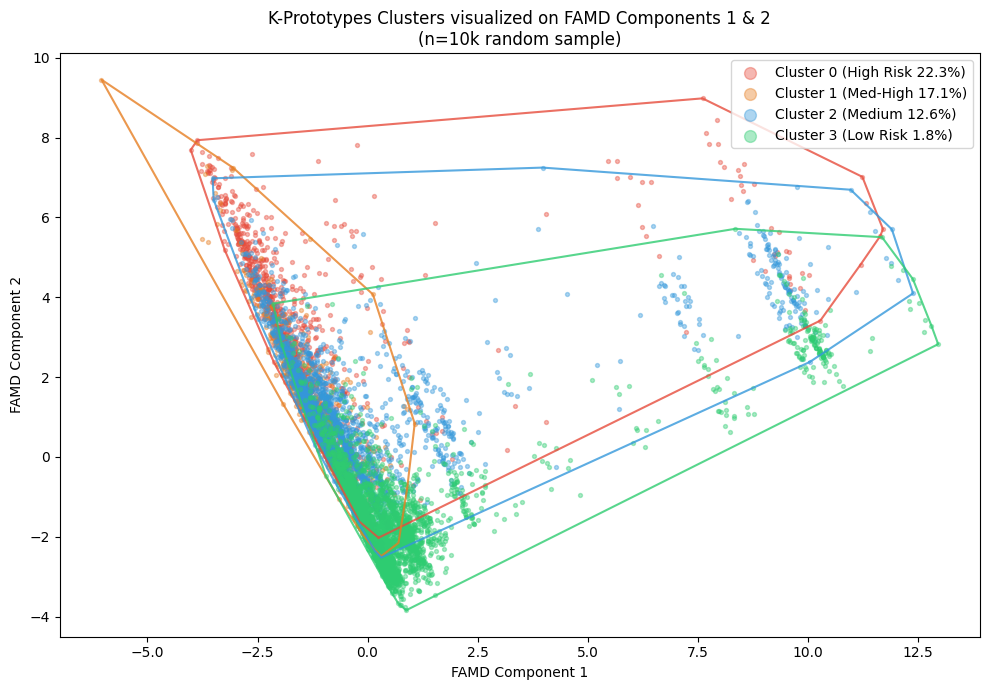

In [33]:
from scipy.spatial import ConvexHull

michd_rates_kp = df_model.groupby("kproto_cluster")[TARGET].mean().round(3)
ranked = michd_rates_kp.sort_values(ascending=False)
risk_labels = ["High Risk", "Med-High", "Medium", "Low Risk"]
risk_map = {cluster: label for cluster, label in zip(ranked.index, risk_labels)}

color_by_risk = {"High Risk": "#e74c3c", "Med-High": "#e67e22",
                 "Medium": "#3498db", "Low Risk": "#2ecc71"}

plot_idx = np.random.choice(len(famd_full_final), size=10000, replace=False)
famd_plot   = famd_full_final[plot_idx, :2]
labels_plot = df_model["kproto_cluster"].values[plot_idx]

fig, ax = plt.subplots(figsize=(10, 7))

for k in sorted(michd_rates_kp.index):
    mask = labels_plot == k
    risk  = risk_map[k]
    color = color_by_risk[risk]
    label = f"Cluster {k} ({risk} {michd_rates_kp[k]*100:.1f}%)"
    points = famd_plot[mask]

    # Scatter points
    ax.scatter(points[:, 0], points[:, 1],
               c=color, label=label, alpha=0.4, s=8)

    # Convex hull outline
    if len(points) >= 3:
        try:
            hull = ConvexHull(points)
            hull_pts = np.append(hull.vertices, hull.vertices[0])
            ax.plot(points[hull_pts, 0], points[hull_pts, 1],
                    color=color, linewidth=1.5, alpha=0.8)
        except Exception:
            pass

ax.set_xlabel("FAMD Component 1")
ax.set_ylabel("FAMD Component 2")
ax.set_title("K-Prototypes Clusters visualized on FAMD Components 1 & 2\n(n=10k random sample)")
ax.legend(markerscale=3, loc="upper right")
plt.tight_layout()
plt.savefig("kproto_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

The scatter plot projects K-Prototypes cluster assignments onto the first two FAMD components for visualization. The diagonal band on the left contains the bulk of respondents, with high-risk clusters (red, orange) concentrating toward the upper portion and the low-risk cluster (green) dominating the lower portion, reflecting a health status gradient along Component 2. An isolated subgroup appears on the right side of the plot, predominantly low-risk, likely representing respondents with a distinct demographic or response pattern in the BRFSS survey. Overlap between clusters is expected since Components 1 and 2 capture only ~10% of total variance, the meaningful separation exists across all 26 original features in the full feature space.


## **5. Gaussian Mixture Modeling (GMM)**

Gaussian Mixture Models (GMM) was selected as the second clustering method because it takes a fundamentally different approach from K-Prototypes. Rather than assigning each respondent to a single hard cluster, GMM models the data as a mixture of Gaussian distributions and produces probabilistic assignments

GMM diag search: 100%|██████████| 7/7 [00:51<00:00,  7.38s/it]


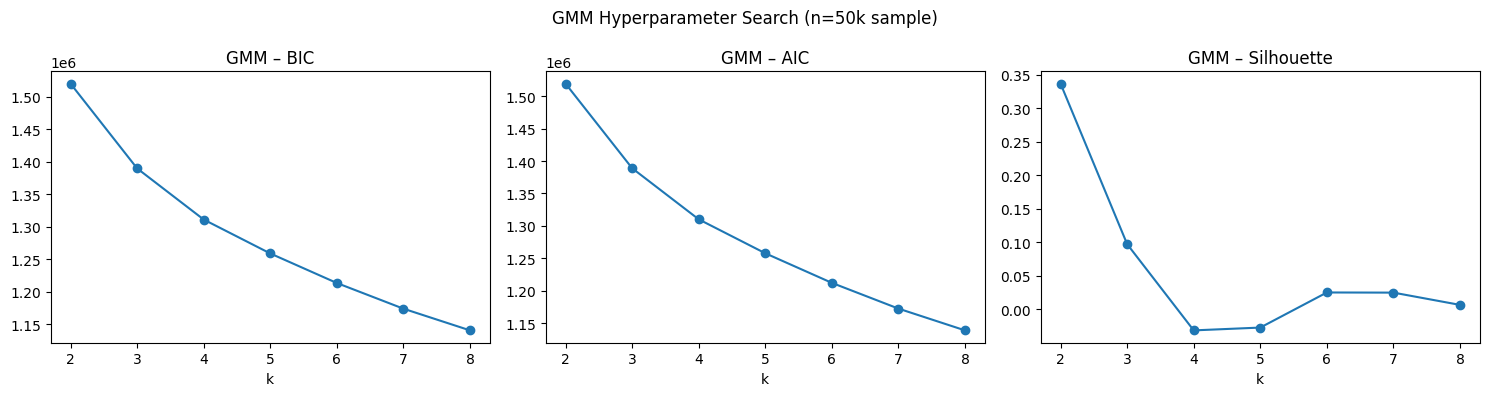

BIC: ['k=2: 1,520,020', 'k=3: 1,389,805', 'k=4: 1,311,218', 'k=5: 1,259,100', 'k=6: 1,213,702', 'k=7: 1,174,246', 'k=8: 1,140,926']
AIC: ['k=2: 1,519,482', 'k=3: 1,388,993', 'k=4: 1,310,133', 'k=5: 1,257,742', 'k=6: 1,212,071', 'k=7: 1,172,341', 'k=8: 1,138,748']
Sil: ['k=2: 0.336', 'k=3: 0.097', 'k=4: -0.031', 'k=5: -0.027', 'k=6: 0.025', 'k=7: 0.025', 'k=8: 0.007']


In [35]:
# Reduce and scale FAMD components for GMM
N_GMM_DIMS = 15
famd_scaler = StandardScaler()
famd_sample_scaled = famd_scaler.fit_transform(famd_sample_final[:, :N_GMM_DIMS])
famd_full_scaled   = famd_scaler.transform(famd_full_final[:, :N_GMM_DIMS])

# Hyperparameter search on scaled 15-dim input
K_RANGE_GMM = range(2, 9)
bic_scores, aic_scores, sil_scores = [], [], []

for k in tqdm(K_RANGE_GMM, desc="GMM diag search"):
    gmm = GaussianMixture(n_components=k, covariance_type="diag", random_state=42, n_init=3)
    gmm.fit(famd_sample_scaled)
    labels = gmm.predict(famd_sample_scaled)
    bic_scores.append(gmm.bic(famd_sample_scaled))
    aic_scores.append(gmm.aic(famd_sample_scaled))
    sil_scores.append(silhouette_score(famd_sample_scaled, labels, sample_size=5000, random_state=42))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(list(K_RANGE_GMM), bic_scores, marker="o")
axes[0].set_title("GMM – BIC")
axes[0].set_xlabel("k")
axes[1].plot(list(K_RANGE_GMM), aic_scores, marker="o")
axes[1].set_title("GMM – AIC")
axes[1].set_xlabel("k")
axes[2].plot(list(K_RANGE_GMM), sil_scores, marker="o")
axes[2].set_title("GMM – Silhouette")
axes[2].set_xlabel("k")

plt.suptitle("GMM Hyperparameter Search (n=50k sample)")
plt.tight_layout()
plt.savefig("gmm_search.png", dpi=150, bbox_inches="tight")
plt.show()

print("BIC:", [f"k={k}: {v:,.0f}" for k, v in zip(K_RANGE_GMM, bic_scores)])
print("AIC:", [f"k={k}: {v:,.0f}" for k, v in zip(K_RANGE_GMM, aic_scores)])
print("Sil:", [f"k={k}: {v:.3f}" for k, v in zip(K_RANGE_GMM, sil_scores)])

The GMM search was run over k=2 to k=8 using diagonal covariance on the 15-dimension scaled FAMD input. BIC and AIC both decreased steadily across all k values, with the largest single drop occurring between k=2 and k=3, after which improvements became progressively smaller (indicating a soft elbow around k=3 to k=4). Silhouette score peaked strongly at k=2 (0.336) then dropped sharply at k=3 (0.097) and turned negative at k=4, suggesting that beyond k=3 clusters begin to overlap in the FAMD space. Balancing the BIC/AIC elbow, silhouette stability, and the need for clinically meaningful subgroups, k=3 was selected as the optimal number of GMM components.

In [36]:
K_GMM_BEST = 3

gmm_final = GaussianMixture(
    n_components=K_GMM_BEST, covariance_type="diag", random_state=42, n_init=5
)
gmm_final.fit(famd_sample_scaled)

df_model["gmm_cluster"]   = gmm_final.predict(famd_full_scaled)
df_model["gmm_proba_max"] = gmm_final.predict_proba(famd_full_scaled).max(axis=1)

print(df_model["gmm_cluster"].value_counts().sort_index())
print(f"\nMICHD rate per GMM cluster:")
print(df_model.groupby("gmm_cluster")[TARGET].mean().round(3))
print(f"\nMean assignment probability:")
print(df_model.groupby("gmm_cluster")["gmm_proba_max"].mean().round(3))

gmm_cluster
0     47134
1    260139
2    145191
Name: count, dtype: int64

MICHD rate per GMM cluster:
gmm_cluster
0    0.118
1    0.123
2    0.033
Name: _MICHD, dtype: float64

Mean assignment probability:
gmm_cluster
0    0.981
1    0.971
2    0.959
Name: gmm_proba_max, dtype: float64


The final GMM model with k=3 assigned all 452,464 records across three clusters with reasonable size distribution. Cluster 2 was the smallest at 145,191 members and had the lowest MICHD rate at 3.3%, representing a low-risk population. Clusters 0 and 1 were larger with 47,134 and 260,139 members respectively, both carrying elevated MICHD rates of 11.8% and 12.3%, representing medium to high risk groups. The MICHD rate spread of 9.0 percentage points (3.3% to 12.3%) confirms meaningful risk stratification across clusters.

In [38]:
# Top 5 most distinguishing continuous features per GMM cluster
global_means = df_model[continuous_cols].mean()
global_stds  = df_model[continuous_cols].std()

cluster_means_gmm = df_model.groupby("gmm_cluster")[continuous_cols].mean()
deviations_gmm = (cluster_means_gmm - global_means) / global_stds

print("=== Top 5 most distinguishing continuous features per GMM cluster ===")
for k in sorted(df_model["gmm_cluster"].unique()):
    michd = df_model.groupby("gmm_cluster")[TARGET].mean()[k]
    print(f"\nCluster {k} (MICHD rate: {michd:.1%}):")
    top5 = deviations_gmm.loc[k].abs().sort_values(ascending=False).head(5)
    for feat in top5.index:
        direction = "↑" if deviations_gmm.loc[k, feat] > 0 else "↓"
        print(f"  {direction} {feat}: {deviations_gmm.loc[k, feat]:+.2f} SD from mean")

# Categorical modes per GMM cluster vs global mode
print("\n=== Top 5 most distinguishing categorical features per GMM cluster ===")
global_modes = df_model[categorical_cols].agg(lambda x: x.mode()[0])
cat_modes_gmm = df_model.groupby("gmm_cluster")[categorical_cols].agg(lambda x: x.mode()[0])

for k in sorted(df_model["gmm_cluster"].unique()):
    michd = df_model.groupby("gmm_cluster")[TARGET].mean()[k]
    print(f"\nCluster {k} (MICHD rate: {michd:.1%}):")
    diffs = cat_modes_gmm.loc[k][cat_modes_gmm.loc[k] != global_modes]
    if len(diffs) > 0:
        print(diffs.head(5).to_string())
    else:
        print("  No distinguishing categorical features")

=== Top 5 most distinguishing continuous features per GMM cluster ===

Cluster 0 (MICHD rate: 11.8%):
  ↑ POORHLTH: +0.26 SD from mean
  ↑ PHYSHLTH: +0.23 SD from mean
  ↑ _LCSYSMK: +0.09 SD from mean
  ↓ _LCSYQTS: -0.07 SD from mean
  ↑ LCSNUMCG: +0.06 SD from mean

Cluster 1 (MICHD rate: 12.3%):
  ↑ _AGEG5YR: +0.17 SD from mean
  ↑ PHYSHLTH: +0.13 SD from mean
  ↑ LCSNUMCG: +0.11 SD from mean
  ↑ _LCSYQTS: +0.10 SD from mean
  ↑ POORHLTH: +0.10 SD from mean

Cluster 2 (MICHD rate: 3.3%):
  ↓ _AGEG5YR: -0.31 SD from mean
  ↓ PHYSHLTH: -0.30 SD from mean
  ↓ POORHLTH: -0.27 SD from mean
  ↓ LCSNUMCG: -0.22 SD from mean
  ↓ _LCSYQTS: -0.16 SD from mean

=== Top 5 most distinguishing categorical features per GMM cluster ===

Cluster 0 (MICHD rate: 11.8%):
_INCOMG1            Unknown
_SMOKER3    Unknown/Refused
PNEUVAC4            Unknown
PRIMINS2           Medicare

Cluster 1 (MICHD rate: 12.3%):
PNEUVAC4         Yes
PRIMINS2    Medicare

Cluster 2 (MICHD rate: 3.3%):
_INCOMG1    $100,00

Cluster 2 (3.3% MICHD) is the most distinct: youngest, healthiest, fewest poor health days, and highest income, representing a low-risk population. Clusters 0 and 1 are less separable from each other, both carrying similar MICHD rates around 12%, with Cluster 1 being slightly older with Medicare insurance and Cluster 0 showing marginally worse current health and more missing income data. The small feature deviations in Clusters 0 and 1 reflect GMM's weaker risk stratification compared to K-Prototypes, consistent with the narrower MICHD spread of 9.0% versus 20.5%.

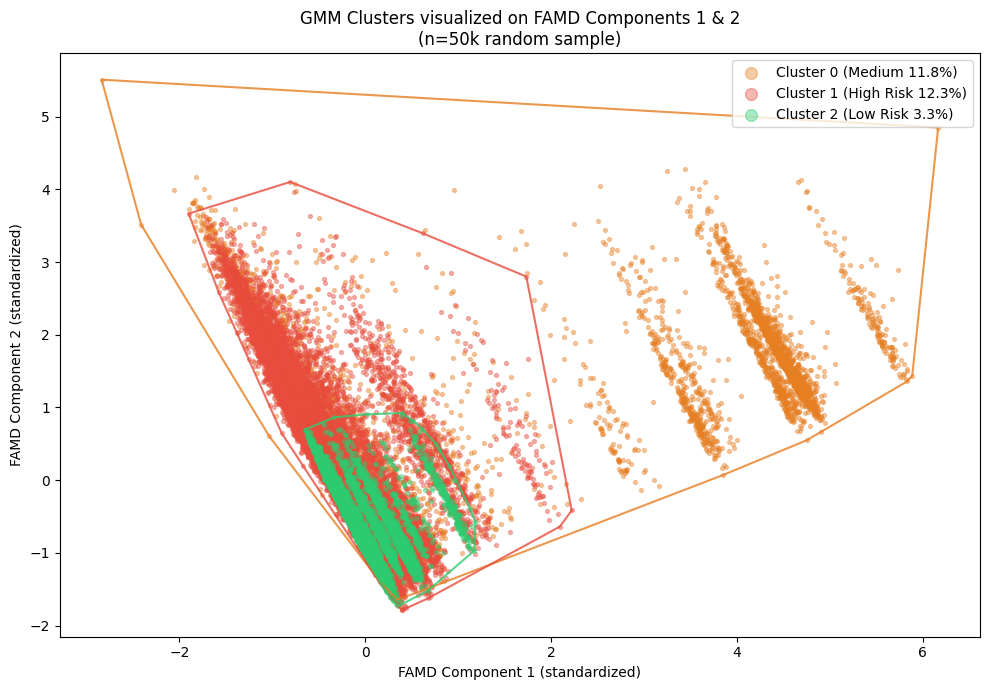

In [39]:
michd_rates_gmm = df_model.groupby("gmm_cluster")[TARGET].mean().round(3)
ranked_gmm = michd_rates_gmm.sort_values(ascending=False)
risk_labels_gmm = ["High Risk", "Medium", "Low Risk"]
risk_map_gmm = {cluster: label for cluster, label in zip(ranked_gmm.index, risk_labels_gmm)}
color_by_risk_gmm = {"High Risk": "#e74c3c", "Medium": "#e67e22", "Low Risk": "#2ecc71"}

plot_idx = np.random.choice(len(famd_full_scaled), size=50_000, replace=False)
famd_plot  = famd_full_scaled[plot_idx, :2]
gmm_labels = df_model["gmm_cluster"].values[plot_idx]

fig, ax = plt.subplots(figsize=(10, 7))

for k in sorted(michd_rates_gmm.index):
    mask = gmm_labels == k
    risk  = risk_map_gmm[k]
    color = color_by_risk_gmm[risk]
    label = f"Cluster {k} ({risk} {michd_rates_gmm[k]*100:.1f}%)"
    points = famd_plot[mask]

    ax.scatter(points[:, 0], points[:, 1],
               c=color, label=label, alpha=0.4, s=8)

    if len(points) >= 3:
        try:
            hull = ConvexHull(points)
            hull_pts = np.append(hull.vertices, hull.vertices[0])
            ax.plot(points[hull_pts, 0], points[hull_pts, 1],
                    color=color, linewidth=1.5, alpha=0.8)
        except Exception:
            pass

ax.set_xlabel("FAMD Component 1 (standardized)")
ax.set_ylabel("FAMD Component 2 (standardized)")
ax.set_title("GMM Clusters visualized on FAMD Components 1 & 2\n(n=50k random sample)")
ax.legend(markerscale=3, loc="upper right")
plt.tight_layout()
plt.savefig("gmm_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

Cluster 2 (green, low risk 3.3%) forms a tight, compact region in the lower-left, reflecting a cohesive group of young healthy respondents with similar response patterns. Cluster 1 (red, high risk 12.3%) overlaps heavily with Cluster 0 (orange, medium 11.8%) in the main band, consistent with their near-identical MICHD rates and small feature deviations. The large orange convex hull extending to the right captures the isolated subgroup seen in previous plots, which GMM assigns to Cluster 0. Overall, the visual confirms GMM's strength in identifying the low-risk group but highlights its difficulty in cleanly separating the two higher-risk clusters.

## **6. Method Comparison and Sensitivity Analysis**

In [43]:
# Compute scores for both methods on the same sample for fair comparison
kproto_labels_sample = df_model["kproto_cluster"].loc[df_sample.index].values
gmm_labels_sample    = df_model["gmm_cluster"].loc[df_sample.index].values

# Silhouette and Davies-Bouldin — use famd_sample_final for both (same space)
sil_kproto = silhouette_score(famd_sample_final, kproto_labels_sample, sample_size=5000, random_state=42)
sil_gmm    = silhouette_score(famd_sample_final, gmm_labels_sample,    sample_size=5000, random_state=42)

db_kproto = davies_bouldin_score(famd_sample_final, kproto_labels_sample)
db_gmm    = davies_bouldin_score(famd_sample_final, gmm_labels_sample)

# BIC/AIC — must use famd_sample_scaled (15 dims, what GMM was fitted on)
bic_final = gmm_final.bic(famd_sample_scaled)
aic_final = gmm_final.aic(famd_sample_scaled)

print("=" * 45)
print(f"{'Metric':<30} {'K-Proto':>7} {'GMM':>7}")
print("=" * 45)
print(f"{'Silhouette':<30} {sil_kproto:>7.3f} {sil_gmm:>7.3f}")
print(f"{'Davies-Bouldin':<30} {db_kproto:>7.3f} {db_gmm:>7.3f}")
print(f"{'BIC (GMM only)':<30} {'N/A':>7} {bic_final:>7,.0f}")
print(f"{'AIC (GMM only)':<30} {'N/A':>7} {aic_final:>7,.0f}")
print("=" * 45)

print(f"\nMICHD rate spread:")
print(f"  K-Prototypes: {df_model.groupby('kproto_cluster')[TARGET].mean().max():.3f} (max) - {df_model.groupby('kproto_cluster')[TARGET].mean().min():.3f} (min) = {df_model.groupby('kproto_cluster')[TARGET].mean().max() - df_model.groupby('kproto_cluster')[TARGET].mean().min():.3f}")
print(f"  GMM:          {df_model.groupby('gmm_cluster')[TARGET].mean().max():.3f} (max) - {df_model.groupby('gmm_cluster')[TARGET].mean().min():.3f} (min) = {df_model.groupby('gmm_cluster')[TARGET].mean().max() - df_model.groupby('gmm_cluster')[TARGET].mean().min():.3f}")

Metric                         K-Proto     GMM
Silhouette                       0.029  -0.013
Davies-Bouldin                   3.944   4.390
BIC (GMM only)                     N/A 1,389,809
AIC (GMM only)                     N/A 1,388,998

MICHD rate spread:
  K-Prototypes: 0.223 (max) - 0.018 (min) = 0.205
  GMM:          0.123 (max) - 0.033 (min) = 0.090


The two methods show a clear tradeoff between cluster quality and clinical risk stratification. GMM produced a negative silhouette score (-0.013) and higher Davies-Bouldin score (4.390) compared to K-Prototypes (0.029 and 3.944 respectively), indicating that GMM clusters are less geometrically cohesive when evaluated in the full 58-dimensional FAMD space. More importantly, K-Prototypes achieved a substantially larger MICHD rate spread of 20.5 percentage points (1.8% to 22.3%) compared to GMM's 9.0 percentage points (3.3% to 12.3%), demonstrating superior clinical risk stratification.

In [46]:
# Sensitivity Analysis — K-Prototypes (takes 15-20 mins to run)
print("=" * 55)
print("Sensitivity Analysis — K-Prototypes (k=4)")
print("=" * 55)

# 1. Sensitivity to random seed
print("\n1. Sensitivity to random seed (n_init=3):")
seeds = [0, 21, 42]
for seed in seeds:
    kp = KPrototypes(n_clusters=4, init="Huang", n_init=3, random_state=seed, verbose=0)
    kp.fit(X_kproto_sample, categorical=cat_idx)
    labels = kp.predict(X_kproto_full, categorical=cat_idx)
    df_model["kproto_temp"] = labels
    spread = df_model.groupby("kproto_temp")[TARGET].mean()
    print(f"  seed={seed}: MICHD spread = {spread.max()-spread.min():.3f}  cost = {kp.cost_:,.0f}")

# 2. Sensitivity to n_init
print("\n2. Sensitivity to n_init (random_state=42):")
for n in [1, 3, 5]:
    kp = KPrototypes(n_clusters=4, init="Huang", n_init=n, random_state=42, verbose=0)
    kp.fit(X_kproto_sample, categorical=cat_idx)
    labels = kp.predict(X_kproto_full, categorical=cat_idx)
    df_model["kproto_temp"] = labels
    spread = df_model.groupby("kproto_temp")[TARGET].mean()
    print(f"  n_init={n:>2}: MICHD spread = {spread.max()-spread.min():.3f}  cost = {kp.cost_:,.0f}")

df_model.drop(columns=["kproto_temp"], inplace=True)

Sensitivity Analysis — K-Prototypes (k=4)

1. Sensitivity to random seed (n_init=3):
  seed=0: MICHD spread = 0.194  cost = 296,220
  seed=21: MICHD spread = 0.205  cost = 290,900
  seed=42: MICHD spread = 0.205  cost = 290,900

2. Sensitivity to n_init (random_state=42):
  n_init= 1: MICHD spread = 0.205  cost = 290,900
  n_init= 3: MICHD spread = 0.205  cost = 290,900
  n_init= 5: MICHD spread = 0.205  cost = 290,900


K-Prototypes showed strong stability across random seeds, with two out of three seeds producing identical MICHD spreads (0.205) and costs (290,900). Seed 0 produced a minor deviation with a spread of 0.194 and slightly higher cost, indicating an occasional suboptimal local minimum. The small magnitude of this difference confirms the solution is robust to initialization randomness. The n_init results further confirm the stability of the solution — all three values (1, 3, and 5 random restarts) produced identical MICHD spreads of 0.205 and costs of 290,900. This means even a single initialization consistently finds the same optimal solution. Combined with the seed sensitivity results, the overall sensitivity analysis demonstrates that the K-Prototypes clustering solution is highly stable and reliable across different hyperparameter choices.

